In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abozeidmohamed/dataset1/label_encoder_classes (1).npy
/kaggle/input/datasets/abozeidmohamed/dataset1/images_over.npy
/kaggle/input/datasets/abozeidmohamed/dataset1/encoded_labels_over (2).npy


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# --- تحميل البيانات --- ✅ الترتيب الصح
X = np.load('/kaggle/input/datasets/abozeidmohamed/dataset1/images_over.npy')        # ← الصور
y = np.load('/kaggle/input/datasets/abozeidmohamed/dataset1/encoded_labels_over (2).npy')  # ← اللابيلز

# لو الصور رمادية نكررها لثلاث قنوات
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)

# ─── التقسيم الثلاثي 70 / 15 / 15 ───────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

# ─── التحقق ──────────────────────────────────────────────────
total = len(X)
print(f"Total  samples : {total}")
print(f"Train  samples : {len(X_train)}  ({len(X_train)/total*100:.1f}%)")
print(f"Val    samples : {len(X_val)}   ({len(X_val)/total*100:.1f}%)")
print(f"Test   samples : {len(X_test)}  ({len(X_test)/total*100:.1f}%)")

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y))

Total  samples : 55520
Train  samples : 38862  (70.0%)
Val    samples : 8330   (15.0%)
Test   samples : 8328  (15.0%)


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [9]:
def build_mobilenetv2(input_shape, num_classes):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Fine-tuning: نفتح آخر 20 طبقة
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


🔢 Calculating FLOPs & MACs...


/tmp/ipykernel_57/3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


  MACs  : 0.34 M  (335872)
  FLOPs : 0.67 M  (671744)

─────────────────────────────────────────────
  🚀 Run 1/10
─────────────────────────────────────────────
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1779359599.550244     129 service.cc:152] XLA service 0x7c5970110a10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779359599.550285     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779359600.995320     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-21 10:33:24.924948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-21 10:

486/608 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.1917 - loss: 3.4333

...

/tmp/ipykernel_57/3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


608/608 ━━━━━━━━━━━━━━━━━━━━ 73s 98ms/step - accuracy: 0.2215 - loss: 3.2228 - val_accuracy: 0.5529 - val_loss: 1.5866 - learning_rate: 1.0000e-04
Epoch 2/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step - accuracy: 0.6341 - loss: 1.1917 - val_accuracy: 0.7497 - val_loss: 0.8713 - learning_rate: 1.0000e-04
Epoch 3/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.7606 - loss: 0.7530 - val_accuracy: 0.8369 - val_loss: 0.5403 - learning_rate: 1.0000e-04
Epoch 4/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.8234 - loss: 0.5444 - val_accuracy: 0.8940 - val_loss: 0.3239 - learning_rate: 1.0000e-04
Epoch 5/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.8616 - loss: 0.4301 - val_accuracy: 0.9245 - val_loss: 0.2364 - learning_rate: 1.0000e-04
Epoch 6/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.8909 - loss: 0.3377 - val_accuracy: 0.9318 - val_loss: 0.2044 - learning_rate: 1.0000e-04
Epoch 7/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accurac

  💾 Test probs saved → /kaggle/working/test_probs_run10.npy  shape: (8328, 32)

  ✅ mob_test_probs.npy — Shape: (8328, 32)
  ✔ Probs sum — min: 1.0000  max: 1.0000


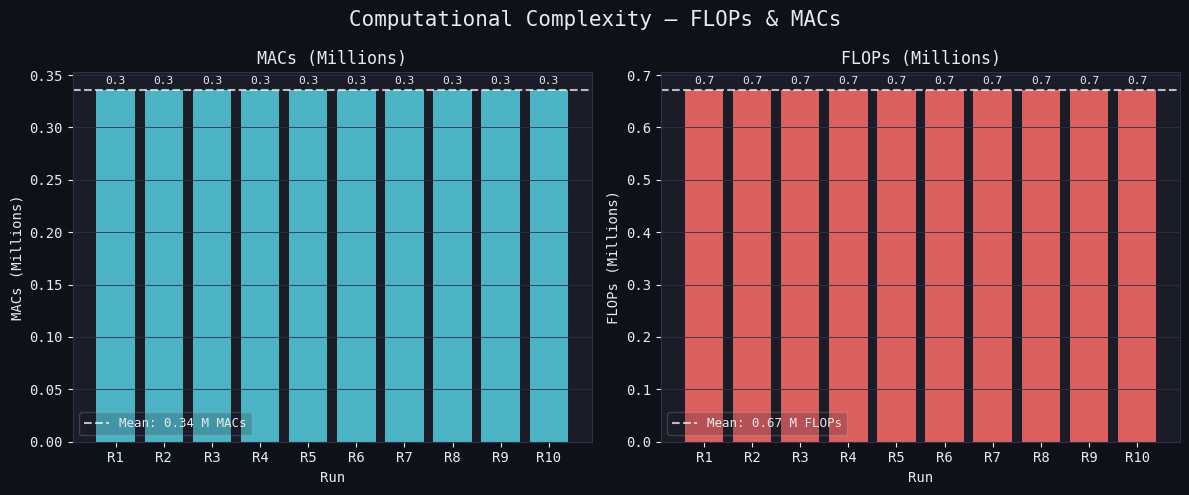

  ✅ saved → /kaggle/working/flops_macs_analysis.png


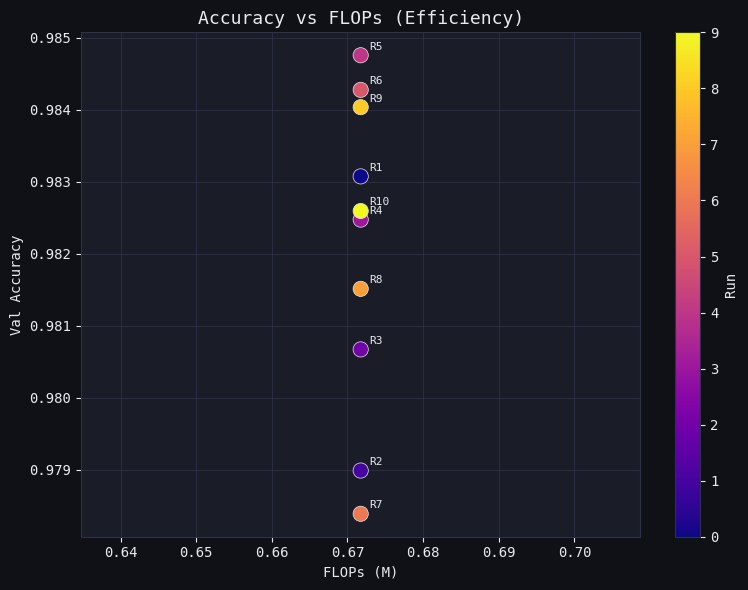

  ✅ saved → /kaggle/working/accuracy_vs_flops.png

  📊 Average Results (VAL) + Complexity:
  Accuracy              : 0.9821
  Loss                  : 0.0558
  MCC                   : 0.9815
  ROC AUC               : 0.9999
  F1 (W)                : 0.9821
  Precision (W)         : 0.9824
  Recall (W)            : 0.9821
  Train Time (s)        : 936.6911
  Infer Total (s)       : 8.6244
  ms / sample           : 1.0353
  Memory (MB)           : 587.4797
  MACs (M)              : 0.3359
  FLOPs (M)             : 0.6717


In [27]:
import gc, time, os, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
import tensorflow.keras.backend as K
from sklearn.metrics import (
    matthews_corrcoef, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ══════════════════════════════════════════════════════
#  حساب FLOPs و MACs
# ══════════════════════════════════════════════════════
def flops_macs_keras(model, input_shape):
    try:
        from keras_flops import get_flops
        flops = get_flops(model, batch_size=1)
        macs  = flops / 2
        return flops, macs
    except ImportError:
        pass

    total_macs = 0
    for layer in model.layers:
        cfg = layer.get_config()
        try:
            if isinstance(layer, tf.keras.layers.Conv2D):
                out_shape = layer.output.shape
                if len(out_shape) == 4:
                    _, H, W, C_out = out_shape
                    kH, kW = (cfg['kernel_size'] if isinstance(cfg['kernel_size'], (list, tuple))
                              else (cfg['kernel_size'], cfg['kernel_size']))
                    C_in = layer.input.shape[-1]
                    total_macs += H * W * C_out * kH * kW * C_in

            elif isinstance(layer, tf.keras.layers.DepthwiseConv2D):
                out_shape = layer.output.shape
                if len(out_shape) == 4:
                    _, H, W, C = out_shape
                    kH, kW = (cfg['kernel_size'] if isinstance(cfg['kernel_size'], (list, tuple))
                              else (cfg['kernel_size'], cfg['kernel_size']))
                    total_macs += H * W * C * kH * kW

            elif isinstance(layer, tf.keras.layers.Dense):
                in_units  = layer.input.shape[-1]
                out_units = cfg['units']
                total_macs += in_units * out_units

        except Exception:
            continue

    total_flops = total_macs * 2
    return total_flops, total_macs


# ═══════════════════════════════════════════════════════════════
#  إعدادات الحفظ والثيم
# ═══════════════════════════════════════════════════════════════
SAVE_DIR = "/kaggle/working/"
os.makedirs(SAVE_DIR, exist_ok=True)

PALETTE = plt.cm.tab10.colors
BG      = "#0f1117"
CARD    = "#1a1d27"
ACCENT  = "#4f8ef7"
TEXT    = "#e8eaf0"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": "#2e3148", "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": "#2e3148",
    "grid.linewidth": 0.6, "font.family": "monospace",
})

def save(name):
    path = os.path.join(SAVE_DIR, name)
    plt.savefig(path, dpi=120, bbox_inches='tight', facecolor=BG)
    plt.show()
    plt.close()
    print(f"  ✅ saved → {path}")


# ═══════════════════════════════════════════════════════════════
#  Storage
# ═══════════════════════════════════════════════════════════════
num_runs             = 10
results              = []
all_histories        = []
all_y_pred           = []
all_y_pred_prob      = []
all_cms              = []
train_times_list     = []
inference_times_list = []
all_test_probs       = []

# ── حساب FLOPs/MACs مرة واحدة ──────────────────────────────
print("🔢 Calculating FLOPs & MACs...")
_temp_model = build_mobilenetv2(input_shape, num_classes)
model_flops, model_macs = flops_macs_keras(_temp_model, input_shape)
del _temp_model; K.clear_session(); gc.collect()

print(f"  MACs  : {model_macs / 1e6:.2f} M  ({model_macs:.0f})")
print(f"  FLOPs : {model_flops / 1e6:.2f} M  ({model_flops:.0f})")


# ═══════════════════════════════════════════════════════════════
#  MAIN LOOP — 10 Runs
# ═══════════════════════════════════════════════════════════════
for run in range(1, num_runs + 1):
    print(f"\n{'─'*45}\n  🚀 Run {run}/{num_runs}\n{'─'*45}")

    start_time = time.time()
    start_mem  = psutil.Process().memory_info().rss / (1024 ** 2)

    model = build_mobilenetv2(input_shape, num_classes)

    early_stop = EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')
    lr_reduce  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=64),
        validation_data=(X_val, y_val),
        epochs=20,
        callbacks=[early_stop, lr_reduce],
        verbose=1,
    )

    end_time     = time.time()
    end_mem      = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time   = end_time - start_time
    train_memory = end_mem - start_mem
    train_times_list.append(train_time)

    # ── Inference ───────────────────────────────────────────
    _ = model.predict(X_val[:8], verbose=0)   # warm-up

    inf_start    = time.time()
    y_pred_probs = model.predict(X_val, verbose=0)
    inf_end      = time.time()

    inference_time          = inf_end - inf_start
    inference_per_sample_ms = inference_time / len(X_val) * 1000
    inference_times_list.append(inference_time)

    y_pred = np.argmax(y_pred_probs, axis=1)

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    cm          = confusion_matrix(y_val, y_pred)
    mcc         = matthews_corrcoef(y_val, y_pred)
    y_val_bin   = label_binarize(y_val, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    except Exception:
        roc_auc = np.nan
    f1_w        = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w    = recall_score(y_val, y_pred, average='weighted')

    print(f"  Val Acc: {val_acc:.4f}  |  Val Loss: {val_loss:.4f}")
    print(f"  MCC: {mcc:.4f}  |  ROC AUC: {roc_auc:.4f}")
    print(f"  F1(W): {f1_w:.4f}  |  Prec(W): {precision_w:.4f}  |  Rec(W): {recall_w:.4f}")
    print(f"  Train: {train_time:.2f}s  |  Infer Total: {inference_time:.4f}s"
          f"  |  Infer/sample: {inference_per_sample_ms:.4f} ms  |  Mem: {train_memory:.2f} MB")
    print(f"  MACs: {model_macs/1e6:.2f}M  |  FLOPs: {model_flops/1e6:.2f}M")

    # ── Test probabilities ───────────────────────────────────
    _ = model.predict(X_test[:8], verbose=0)   # warm-up
    test_probs = model.predict(X_test, verbose=0)
    all_test_probs.append(test_probs)

    test_probs_path = os.path.join(SAVE_DIR, f"test_probs_run{run}.npy")
    np.save(test_probs_path, test_probs)
    print(f"  💾 Test probs saved → {test_probs_path}  shape: {test_probs.shape}")

    model_path = os.path.join(SAVE_DIR, f"model_run{run}.h5")
    model.save(model_path)

    all_histories.append(history)
    all_y_pred.append(y_pred)
    all_y_pred_prob.append(y_pred_probs)
    all_cms.append(cm)

    results.append({
        "Run":                      run,
        "Val_Accuracy":             val_acc,
        "Val_Loss":                 val_loss,
        "MCC":                      mcc,
        "ROC_AUC":                  roc_auc,
        "F1_Weighted":              f1_w,
        "Precision_Weighted":       precision_w,
        "Recall_Weighted":          recall_w,
        "Training_Time(s)":         train_time,
        "Inference_Total(s)":       inference_time,
        "Inference_ms_per_sample":  inference_per_sample_ms,
        "Memory_Used(MB)":          train_memory,
        "MACs(M)":                  model_macs / 1e6,
        "FLOPs(M)":                 model_flops / 1e6,
    })

    del model, history, y_pred, y_pred_probs, test_probs
    K.clear_session()
    gc.collect()


# ═══════════════════════════════════════════════════════════════
#  mob_test_probs — average الـ 10 runs
# ═══════════════════════════════════════════════════════════════
mob_test_probs = np.stack(all_test_probs, axis=0).mean(axis=0)

np.save(os.path.join(SAVE_DIR, "mob_test_probs.npy"), mob_test_probs)

print(f"\n  ✅ mob_test_probs.npy — Shape: {mob_test_probs.shape}")
sums = mob_test_probs.sum(axis=1)
print(f"  ✔ Probs sum — min: {sums.min():.4f}  max: {sums.max():.4f}")


# ═══════════════════════════════════════════════════════════════
#  AGGREGATE PLOTS
# ═══════════════════════════════════════════════════════════════
df_metrics  = pd.DataFrame(results)
avg_results = df_metrics.mean(numeric_only=True)
run_labels  = [f"R{r}" for r in range(1, num_runs + 1)]

# ── FLOPs / MACs Summary Panel ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Computational Complexity — FLOPs & MACs", color=TEXT, fontsize=15)

for ax, col, ylabel, color, unit in [
    (axes[0], "MACs(M)",  "MACs (Millions)",  "#56cfe1", "M MACs"),
    (axes[1], "FLOPs(M)", "FLOPs (Millions)", "#ff6b6b", "M FLOPs"),
]:
    ax.set_facecolor(CARD)
    bars = ax.bar(run_labels, df_metrics[col], color=color, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, df_metrics[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8, color=TEXT)
    ax.axhline(df_metrics[col].mean(), color='white', lw=1.5, linestyle='--', alpha=0.7,
               label=f"Mean: {df_metrics[col].mean():.2f} {unit}")
    ax.set_xlabel("Run"); ax.set_ylabel(ylabel); ax.set_title(ylabel, color=TEXT)
    ax.legend(fontsize=9, framealpha=0.2); ax.grid(True, axis='y')
    for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")

plt.tight_layout()
save("flops_macs_analysis.png")

# ── Accuracy vs FLOPs ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
sc = ax.scatter(df_metrics["FLOPs(M)"], df_metrics["Val_Accuracy"],
                c=range(num_runs), cmap="plasma", s=120, zorder=5,
                edgecolors=TEXT, linewidths=0.5)
for _, row in df_metrics.iterrows():
    ax.annotate(f"R{int(row['Run'])}",
                (row["FLOPs(M)"], row["Val_Accuracy"]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=8, color=TEXT)
ax.set_xlabel("FLOPs (M)"); ax.set_ylabel("Val Accuracy")
ax.set_title("Accuracy vs FLOPs (Efficiency)", color=TEXT, fontsize=13)
ax.grid(True)
for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")
plt.colorbar(sc, ax=ax, label="Run")
plt.tight_layout()
save("accuracy_vs_flops.png")


# ═══════════════════════════════════════════════════════════════
#  Excel
# ═══════════════════════════════════════════════════════════════
summary_cols = [
    "Val_Accuracy", "Val_Loss", "MCC", "ROC_AUC", "F1_Weighted",
    "Precision_Weighted", "Recall_Weighted",
    "Training_Time(s)", "Inference_Total(s)",
    "Inference_ms_per_sample", "Memory_Used(MB)",
    "MACs(M)", "FLOPs(M)",
]

excel_path = os.path.join(SAVE_DIR, "mobilenetv2_full_analysis.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    df_metrics.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")
    df_metrics[summary_cols].describe().round(4).to_excel(writer, sheet_name="Stats")

# ── ملخص نهائي ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("  📊 Average Results (VAL) + Complexity:")
print("=" * 55)
for col, lbl in [
    ("Val_Accuracy",           "Accuracy"),
    ("Val_Loss",               "Loss"),
    ("MCC",                    "MCC"),
    ("ROC_AUC",                "ROC AUC"),
    ("F1_Weighted",            "F1 (W)"),
    ("Precision_Weighted",     "Precision (W)"),
    ("Recall_Weighted",        "Recall (W)"),
    ("Training_Time(s)",       "Train Time (s)"),
    ("Inference_Total(s)",     "Infer Total (s)"),
    ("Inference_ms_per_sample","ms / sample"),
    ("Memory_Used(MB)",        "Memory (MB)"),
    ("MACs(M)",                "MACs (M)"),
    ("FLOPs(M)",               "FLOPs (M)"),
]:
    print(f"  {lbl:<22}: {avg_results[col]:.4f}")
print("=" * 55)

In [28]:
import tensorflow as tf
import pandas as pd
import os

# ── اختار أحسن run بناءً على Val Accuracy ────────────────────
df_metrics = pd.DataFrame(results)
best_run    = int(df_metrics.loc[df_metrics['Val_Accuracy'].idxmax(), 'Run'])
print(f"  🏆 Best Run: {best_run}  (Val Acc: {df_metrics['Val_Accuracy'].max():.4f})")

# ── تحميل الموديل ─────────────────────────────────────────────
model_path = f"/kaggle/working/model_run{best_run}.h5"
model      = tf.keras.models.load_model(model_path)
print(f"  ✅ Model loaded from: {model_path}")
print(f"  📐 Input shape: {model.input_shape}")

  🏆 Best Run: 5  (Val Acc: 0.9848)


  ✅ Model loaded from: /kaggle/working/model_run5.h5
  📐 Input shape: (None, 64, 64, 3)


In [30]:
import numpy as np

# ── تحميل الـ class names ─────────────────────────────────────
class_names = np.load(
    '/kaggle/input/datasets/abozeidmohamed/dataset1/label_encoder_classes (1).npy',
    allow_pickle=True
)

print(f"✅ class_names loaded: {class_names}")
print(f"   عدد الكلاسات: {len(class_names)}")

✅ class_names loaded: ['ain' 'al' 'aleff' 'bb' 'dal' 'dha' 'dhad' 'fa' 'gaaf' 'ghain' 'ha' 'haa'
 'jeem' 'kaaf' 'khaa' 'la' 'laam' 'meem' 'nun' 'ra' 'saad' 'seen' 'sheen'
 'ta' 'taa' 'thaa' 'thal' 'toot' 'waw' 'ya' 'yaa' 'zay']
   عدد الكلاسات: 32


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPLETE LIME + QUANTITATIVE XAI (10 INDIVIDUAL REPORT IMAGES)
# ══════════════════════════════════════════════════════════════════════════════

!pip install lime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries
from skimage.transform import resize
from scipy.ndimage import gaussian_filter
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

tf.keras.backend.clear_session()

# ══════════════════════════════════════════════════════════════════════════════
# MODEL INFO
# ══════════════════════════════════════════════════════════════════════════════

H, W, C = model.input_shape[1:]
print("Model Input Shape:", model.input_shape)

# ══════════════════════════════════════════════════════════════════════════════
# STYLE
# ══════════════════════════════════════════════════════════════════════════════

BG = "#0f1117"
CARD = "#1a1d27"
TEXT = "#e8eaf0"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": CARD,
    "axes.edgecolor": "#2e3148",
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "font.family": "monospace",
})

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def to_rgb(image):
    im = np.asarray(image).astype("float32")

    if im.ndim == 2:
        im = np.repeat(im[..., None], 3, axis=-1)
    elif im.shape[-1] == 1:
        im = np.repeat(im, 3, axis=-1)

    im = im[..., :3]

    if im.max() > 1:
        im /= 255.0

    return np.clip(im, 0, 1)


def preprocess_batch(images):
    out = []

    for im in images:
        im = np.asarray(im).astype("float32")

        if C == 1:
            if im.ndim == 3:
                im = np.mean(im, axis=-1, keepdims=True)
            im = resize(im, (H, W, 1), preserve_range=True)
        else:
            if im.ndim == 2:
                im = np.repeat(im[..., None], 3, axis=-1)
            im = im[..., :3]
            im = resize(im, (H, W, 3), preserve_range=True)

        if im.max() > 1:
            im /= 255.0

        out.append(im.astype("float32"))

    return np.array(out)


def predict_fn(images):
    return model.predict(preprocess_batch(images), verbose=0)


def get_conf(img, cls):
    return model.predict(preprocess_batch([img]), verbose=0)[0][cls]


def blur(img):
    return gaussian_filter(img, sigma=10)


# ══════════════════════════════════════════════════════════════════════════════
# CONFIDENCE HEATMAP
# ══════════════════════════════════════════════════════════════════════════════

def confidence_heatmap(image, cls, grid=14):
    h, w = image.shape[:2]
    heat = np.zeros((grid, grid))

    bh, bw = h // grid, w // grid
    base = get_conf(image, cls)

    for i in range(grid):
        for j in range(grid):

            temp = image.copy()
            temp[i*bh:(i+1)*bh, j*bw:(j+1)*bw] = 0

            heat[i, j] = base - get_conf(temp, cls)

    return np.maximum(heat, 0)


# ══════════════════════════════════════════════════════════════════════════════
# LIME
# ══════════════════════════════════════════════════════════════════════════════

explainer = lime_image.LimeImageExplainer(random_state=42)

# ══════════════════════════════════════════════════════════════════════════════
# SAMPLE SELECTION
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(42)

n_explain = 10
indices = np.random.choice(len(x_val), n_explain, replace=False)

# ══════════════════════════════════════════════════════════════════════════════
# MAIN LOOP
# ══════════════════════════════════════════════════════════════════════════════

for i, idx in enumerate(indices, 1):

    print("\n" + "="*70)
    print(f"SAMPLE {i}/{n_explain}")
    print("="*70)

    image = x_val[idx]
    image_rgb = to_rgb(image)
    true_label = int(y_val[idx])

    preds = model.predict(preprocess_batch([image]), verbose=0)[0]
    pred_label = np.argmax(preds)
    conf = preds[pred_label]

    print("True :", class_names[true_label])
    print("Pred :", class_names[pred_label])
    print("Conf :", f"{conf:.2%}")

    # ═════════ LIME ═════════
    explanation = explainer.explain_instance(
        image_rgb.astype("double"),
        classifier_fn=predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000,
        segmentation_fn=lambda x: slic(x, n_segments=100, compactness=10)
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        label=pred_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    importance_mask = (lime_mask > 0).astype(np.uint8)

    # ═════════ HEATMAP ═════════
    conf_map = confidence_heatmap(image_rgb, pred_label)

    # ═════════ PLOT ═════════
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.patch.set_facecolor(BG)

    # Original
    axes[0, 0].imshow(image_rgb)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")

    # LIME overlay
    overlay = mark_boundaries(lime_img, lime_mask)
    axes[0, 1].imshow(overlay)
    axes[0, 1].set_title("LIME Overlay")
    axes[0, 1].axis("off")

    # Importance
    axes[0, 2].imshow(lime_mask, cmap="hot")
    axes[0, 2].set_title("Importance Map")
    axes[0, 2].axis("off")

    # Confidence heatmap
    axes[1, 0].imshow(conf_map, cmap="viridis")
    axes[1, 0].set_title("Confidence Drop Heatmap")
    axes[1, 0].axis("off")

    # Probabilities
    axes[1, 1].bar(range(len(preds)), preds)
    axes[1, 1].set_title("Class Probabilities")

    # Text summary
    axes[1, 2].text(
        0.1, 0.6,
        f"Pred: {class_names[pred_label]}\nConfidence: {conf:.2%}",
        fontsize=14
    )
    axes[1, 2].axis("off")

    plt.tight_layout()

    # ═════════ SAVE ═════════
    path = f"/kaggle/working/XAI_REPORT_{i}.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()

    print("Saved:", path)

print("\nDONE: 10 XAI REPORT IMAGES GENERATED")

Model Input Shape: (None, 64, 64, 3)


NameError: name 'x_val' is not defined

In [32]:
import tensorflow as tf
from tensorflow.python.framework import convert_to_constants

# ─────────────────────────────────────────────
# 1) نجيب input shape من الموديل
# ─────────────────────────────────────────────
input_shape = model.input_shape

# لو فيه batch None نخليه 1
input_shape = tuple([1 if x is None else x for x in input_shape])

print("  📐 Used input shape for FLOPs:", input_shape)


# ─────────────────────────────────────────────
# 2) FLOPs function
# ─────────────────────────────────────────────
def get_flops(model, input_shape):

    full_model = tf.function(lambda x: model(x))
    full_model = full_model.get_concrete_function(
        tf.TensorSpec(input_shape, tf.float32)
    )

    frozen_func = convert_to_constants.convert_variables_to_constants_v2(full_model)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.import_graph_def(graph_def, name="")

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd="op",
            options=opts
        )

        return flops.total_float_ops


# ─────────────────────────────────────────────
# 3) الحساب
# ─────────────────────────────────────────────
flops = get_flops(model, input_shape)

flops_m = flops / 1e6
macs_m  = flops_m / 2   # approximation

# ─────────────────────────────────────────────
# 4) output
# ─────────────────────────────────────────────
print("\n==============================")
print("  ⚡ Model Complexity")
print("==============================")
print(f"FLOPs  : {flops_m:.4f} M")
print(f"MACs   : {macs_m:.4f} M")

  📐 Used input shape for FLOPs: (1, 64, 64, 3)


I0000 00:00:1779369462.519207      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779369462.519429      57 single_machine.cc:374] Starting new session
I0000 00:00:1779369462.520459      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th